<a href="https://colab.research.google.com/github/rafaelromwno/am-t4-s1a2026/blob/main/aula-11/MultiNeuralCredit0512.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Pipeline Naive Bayes | Digest GaussianNB [Fase 1 - credit_data]

## Importar dados do Google Drive

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Bibliotecas de Python

In [8]:
!pip -q install plotly
!pip -q install yellowbrick

In [33]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

## Carregar Digest de base_credit

In [10]:
import pickle

In [11]:
with open('/content/drive/MyDrive/Eu/FATEC/CICLO-V/ML/P1/credit.pkl', mode = 'rb') as f:
   X_credit_treinamento, Y_credit_treinamento, X_credit_teste, Y_credit_teste = pickle.load(f)

In [12]:
X_credit_treinamento.shape, Y_credit_treinamento.shape

((1700, 3), (1700,))

In [13]:
X_credit_teste.shape, Y_credit_teste.shape

((300, 3), (300,))

In [14]:
from sklearn.naive_bayes import GaussianNB

In [15]:
naive_credit_data = GaussianNB()
naive_credit_data.fit(X_credit_treinamento, Y_credit_treinamento)

GaussianNB()


# Pipeline Árvore de Decisão | Treemap Base [Fase 2 - credit_data]

In [16]:
from sklearn.tree import DecisionTreeClassifier

In [17]:
# cria o modelo de árvore de decisão
arvore_credit_data = DecisionTreeClassifier(

    # define o critério de divisão dos nós da árvore 'entropy' utiliza o cálculo de entropia para medir a impureza dos dados
    criterion='entropy',

    # define uma semente fixa para gerar sempre os mesmos resultados aleatórios
    random_state=0
)

# treina a árvore de decisão utilizando:
# X_credit_treinamento -> atributos de entrada
# Y_credit_treinamento -> classes/respostas corretas
arvore_credit_data.fit(
    X_credit_treinamento,
    Y_credit_treinamento
)

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [19]:
# cria o modelo de árvore de decisão
modelo = DecisionTreeClassifier(

    # controle de poda da árvore (Cost Complexity Pruning) quanto maior o valor, mais simples será a árvore
    ccp_alpha=0.0,

    # define pesos para as classes none = todas as classes possuem o mesmo peso
    class_weight=None,

    # critério usado para medir a qualidade das divisões "entropy" utiliza ganho de informação baseado em entropia
    criterion="entropy",

    # profundidade máxima da árvore None = cresce até o limite dos dados
    max_depth=None,

    # número máximo de atributos analisados em cada divisão None = utiliza todos os atributos disponíveis
    max_features=None,

    # número máximo de nós folha None = sem limite de folhas
    max_leaf_nodes=None,

    # quantidade mínima de amostras em cada folha final
    min_samples_leaf=1,

    # quantidade mínima de amostras para dividir um nó
    min_samples_split=2,

    # fração mínima ponderada necessária em uma folha
    min_weight_fraction_leaf=0.0,

    # define uma semente fixa para reproduzir os mesmos resultados
    random_state=0,

    # estratégia utilizada para escolher a melhor divisão "best" = escolhe a melhor divisão possível
    splitter='best'
)

In [21]:
previsoes_arvore = arvore_credit_data.predict(X_credit_teste)

In [22]:
previsoes_arvore

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0])

In [24]:
Y_credit_teste

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0])

In [23]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [25]:
accuracy_score(Y_credit_teste, previsoes_arvore)

0.9733333333333334

In [26]:
from yellowbrick.classifier import ConfusionMatrix

In [28]:
print(classification_report(Y_credit_teste, previsoes_arvore))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98       260
           1       0.86      0.95      0.90        40

    accuracy                           0.97       300
   macro avg       0.93      0.96      0.94       300
weighted avg       0.98      0.97      0.97       300



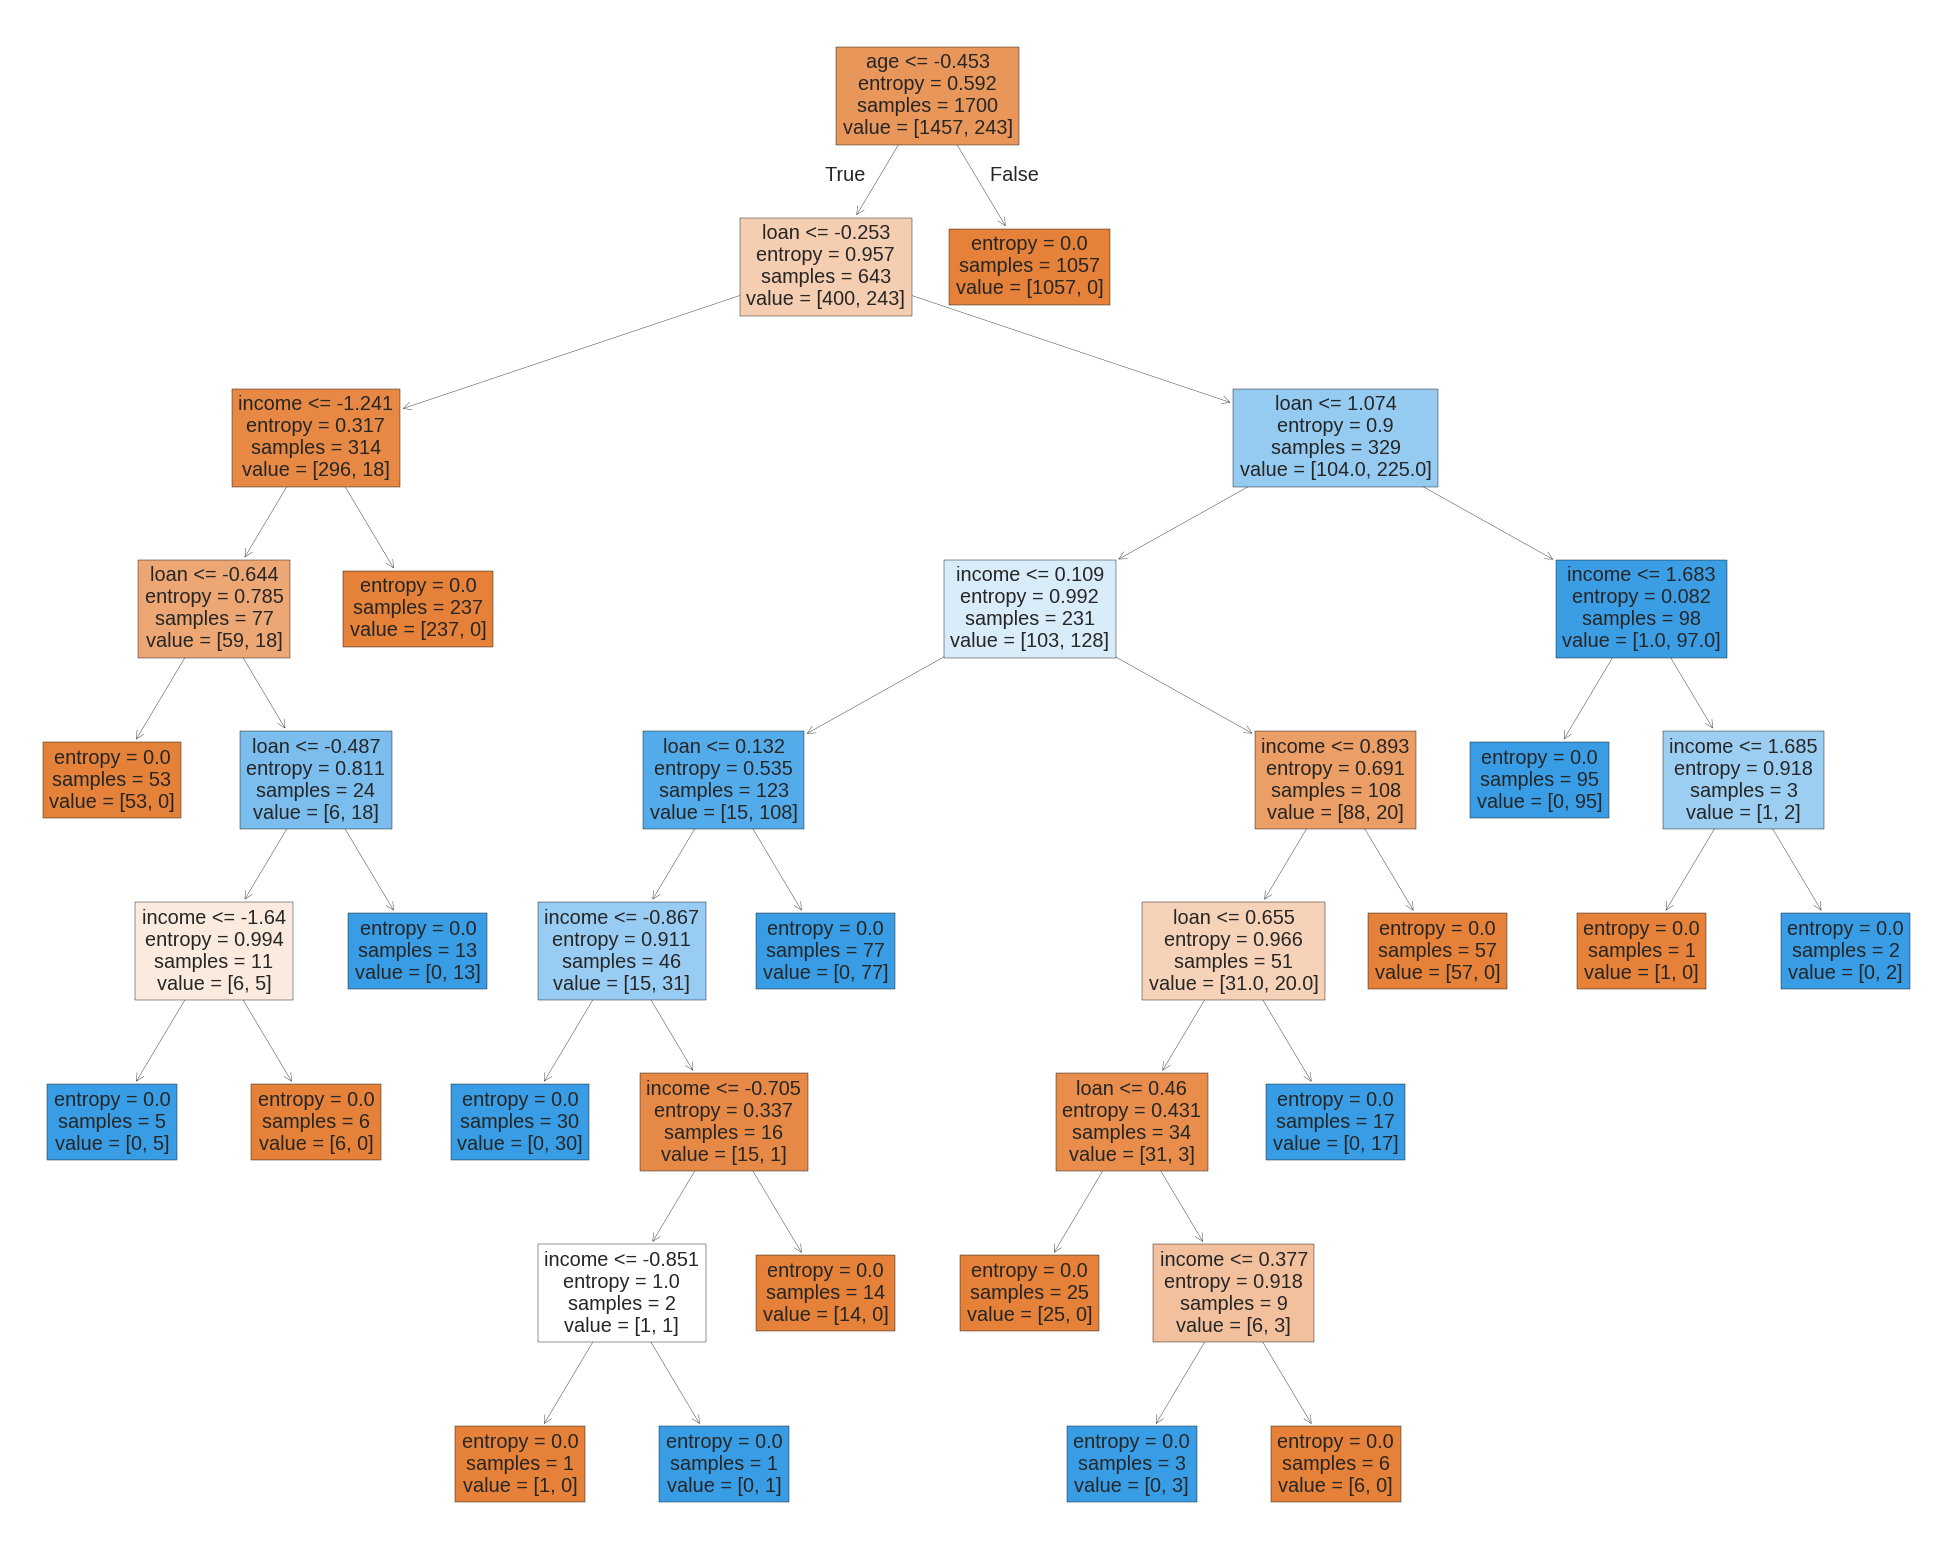

In [34]:
from sklearn import tree
previsoes_arvore = ['income', 'age', 'loan']
fig = plt.figure(figsize=(25,20))
tree.plot_tree(arvore_credit_data, feature_names=previsoes_arvore, filled=True)
plt.show()